In [2]:
import pandas as pd
import numpy as np

# 1) Load
df = pd.read_csv("Dataset .csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()
print(df.shape)
display(df.head())

# 2) Basic cleaning
df_clean = df.copy()

# strip column names
df_clean.columns = [c.strip() for c in df_clean.columns]

# strip whitespace in text columns + convert "nan"/"" -> NaN
obj_cols = df_clean.select_dtypes(include="object").columns
for c in obj_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()
    df_clean.loc[df_clean[c].str.lower().isin(["nan","none","null",""]), c] = np.nan

# Yes/No -> 1/0
yn_cols = ["Has Table booking","Has Online delivery","Is delivering now","Switch to order menu"]
for c in yn_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].map({"Yes": 1, "No": 0})

# numeric columns
num_cols = ["Longitude","Latitude","Average Cost for two","Price range","Aggregate rating","Votes",
            "Country Code","Restaurant ID"]
for c in num_cols:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# Remove duplicate restaurant IDs 
if "Restaurant ID" in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=["Restaurant ID"])

df_clean["Aggregate rating_clean"] = df_clean["Aggregate rating"].replace({0: np.nan})

print("After cleaning:", df_clean.shape)
display(df_clean.head())


(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


After cleaning: (9551, 22)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Aggregate rating_clean
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,1,0,0,0,3,4.8,Dark Green,Excellent,314,4.8
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,1,0,0,0,3,4.5,Dark Green,Excellent,591,4.5
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,1,0,0,0,4,4.4,Green,Very Good,270,4.4
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,0,0,0,0,4,4.9,Dark Green,Excellent,365,4.9
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,1,0,0,0,4,4.8,Dark Green,Excellent,229,4.8


Top 3 cuisines:
 Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

% restaurants serving each of top cuisines:
North Indian: 41.46%
Chinese: 28.61%
Fast Food: 20.79%

City with highest restaurants: New Delhi (5473)
Average rating in New Delhi (excluding 0/not-rated): 3.297

Best city by average rating (overall):


,n,rated_n,avg_rating
City,,,
Inner City,2,2,4.9


Best city by average rating (min 20 rated restaurants):


,n,rated_n,avg_rating
City,,,
London,20,20,4.535


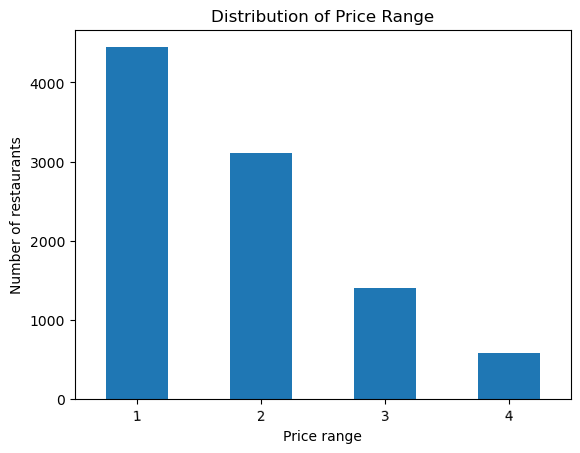


% restaurants in each price range:


Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


% restaurants offering online delivery: 25.66%

Avg rating (excluding 0/not-rated):
0 = No delivery, 1 = Delivery


Has Online delivery
0    3.467433
1    3.381274
Name: Aggregate rating_clean, dtype: float64


Review text columns found: []
skipped: No review text column in this CSV.
No review text column in this CSV.

Highest votes restaurant:


...

Restaurant Name     Cantinho da Gula
City                      S��o Paulo
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object


Correlation (Votes vs Rating): 0.409

Service rates by price range:


,n,online_delivery_rate,table_booking_rate
Price range,,,
1,4444,0.157741,0.000225
2,3113,0.413106,0.076775
3,1408,0.291903,0.457386
4,586,0.090444,0.467577



Comparing low price (1-2) vs high price (3-4):
High_price: 0 = Price range 1-2, 1 = Price range 3-4


,n,online_delivery_rate,table_booking_rate
High_price,,,
0,7557,0.262935,0.031759
1,1994,0.232698,0.460381


In [3]:
import matplotlib.pyplot as plt

total_restaurants = len(df_clean)

#Top 3 cuisines
cuisine_exploded = df_clean["Cuisines"].dropna().str.split(",").explode().str.strip()
top3_cuisines = cuisine_exploded.value_counts().head(3)
print("Top 3 cuisines:\n", top3_cuisines)

#restaurants serving each top cuisine
perc_top = {}
for cuisine in top3_cuisines.index:
    mask = df_clean["Cuisines"].fillna("").str.split(",").apply(lambda lst: cuisine in [x.strip() for x in lst])
    perc_top[cuisine] = mask.mean() * 100
print("\n% restaurants serving each of top cuisines:")
for k,v in perc_top.items():
    print(f"{k}: {v:.2f}%")

#City with highest number of restaurants
city_counts = df_clean["City"].value_counts()
top_city = city_counts.idxmax()
top_city_count = city_counts.max()
print(f"\nCity with highest restaurants: {top_city} ({top_city_count})")

#Avg rating in that city
avg_rating_top_city = df_clean.loc[df_clean["City"]==top_city, "Aggregate rating_clean"].mean()
print(f"Average rating in {top_city} (excluding 0/not-rated): {avg_rating_top_city:.3f}")

#City with highest average rating
city_stats = df_clean.groupby("City").agg(
    n=("Restaurant ID","count"),
    rated_n=("Aggregate rating_clean","count"),
    avg_rating=("Aggregate rating_clean","mean")
)

best_city_overall = city_stats.sort_values("avg_rating", ascending=False).head(1)
best_city_min20 = city_stats[city_stats["rated_n"]>=20].sort_values("avg_rating", ascending=False).head(1)

print("\nBest city by average rating (overall):")
display(best_city_overall)

print("Best city by average rating (min 20 rated restaurants):")
display(best_city_min20)

#Plot price range distribution
price_counts = df_clean["Price range"].value_counts().sort_index()
plt.figure()
price_counts.plot(kind="bar")
plt.xticks(rotation=3)
plt.title("Distribution of Price Range")
plt.xlabel("Price range")
plt.ylabel("Number of restaurants")
plt.show()

#restaurants in each price range
price_perc = (price_counts / total_restaurants) * 100
print("\n% restaurants in each price range:")
display(price_perc)

#offering online delivery
online_delivery_pct = df_clean["Has Online delivery"].mean() * 100
print(f"\n% restaurants offering online delivery: {online_delivery_pct:.2f}%")

#Compare avg ratings with/without delivery
avg_by_delivery = df_clean.groupby("Has Online delivery")["Aggregate rating_clean"].mean()
print("\nAvg rating (excluding 0/not-rated):")
print("0 = No delivery, 1 = Delivery")
display(avg_by_delivery)

#Review keyword analysis
possible_review_cols = [c for c in df_clean.columns if str(c).lower() in ["review","reviews","review text","text","comments","comment"]]
print("\nReview text columns found:", possible_review_cols)

if possible_review_cols:
    review_col = possible_review_cols[0]
    text = df_clean[review_col].dropna().astype(str).str.lower()

    positive_words = ["good","great","excellent","amazing","nice","love","awesome","best","tasty","delicious"]
    negative_words = ["bad","worst","poor","terrible","awful","slow","rude","waste","disgusting","cold"]

    def count_keywords(series, words):
        counts = {}
        for w in words:
            counts[w] = series.str.contains(rf"\b{w}\b", regex=True).sum()
        return pd.Series(counts).sort_values(ascending=False)

    print("\nMost common positive keywords:")
    display(count_keywords(text, positive_words))

    print("Most common negative keywords:")
    display(count_keywords(text, negative_words))
else:
    print("skipped: No review text column in this CSV.")

#Avg review length + relationship with rating (ONLY if review text exists)
if possible_review_cols:
    review_col = possible_review_cols[0]
    df_tmp = df_clean.dropna(subset=[review_col, "Aggregate rating_clean"]).copy()
    df_tmp["review_length"] = df_tmp[review_col].astype(str).str.len()

    print("\nAverage review length:", df_tmp["review_length"].mean())

    corr_len_rating = df_tmp[["review_length","Aggregate rating_clean"]].corr().iloc[0,1]
    print("Correlation between review length and rating:", corr_len_rating)

    plt.figure()
    plt.scatter(df_tmp["review_length"], df_tmp["Aggregate rating_clean"])
    plt.xlabel("Review length")
    plt.ylabel("Aggregate rating (clean)")
    plt.title("Review Length vs Rating")
    plt.show()
else:
    print("No review text column in this CSV.")

#Restaurants with highest and lowest votes
max_votes_row = df_clean.loc[df_clean["Votes"].idxmax(), ["Restaurant Name","City","Votes","Aggregate rating"]]
min_votes_row = df_clean.loc[df_clean["Votes"].idxmin(), ["Restaurant Name","City","Votes","Aggregate rating"]]
print("\nHighest votes restaurant:")
display(max_votes_row)
print("Lowest votes restaurant:")
display(min_votes_row)

#Correlation between votes and rating
df_corr = df_clean[["Votes","Aggregate rating_clean"]].dropna()
corr_votes_rating = df_corr.corr().iloc[0,1]
print(f"\nCorrelation (Votes vs Rating): {corr_votes_rating:.3f}")

#Relationship between price range and delivery + table booking
service_by_price = df_clean.groupby("Price range").agg(
    n=("Restaurant ID","count"),
    online_delivery_rate=("Has Online delivery","mean"),
    table_booking_rate=("Has Table booking","mean")
)
print("\nService rates by price range:")
display(service_by_price)

#Are higher-priced restaurants more likely to offer these services
df_clean["High_price"] = (df_clean["Price range"] >= 3).astype(int)

rates = df_clean.groupby("High_price").agg(
    n=("Restaurant ID","count"),
    online_delivery_rate=("Has Online delivery","mean"),
    table_booking_rate=("Has Table booking","mean")
)

print("\nComparing low price (1-2) vs high price (3-4):")
print("High_price: 0 = Price range 1-2, 1 = Price range 3-4")
display(rates)




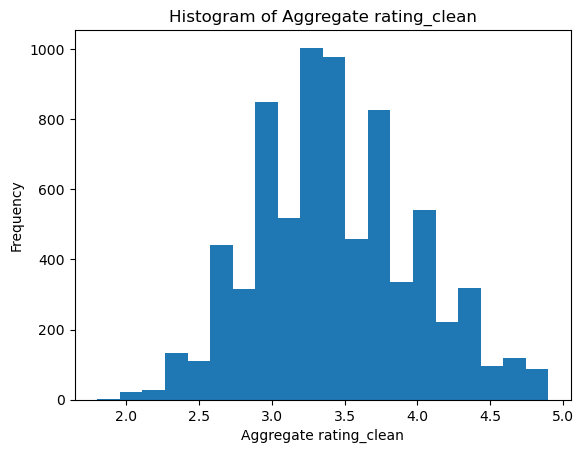

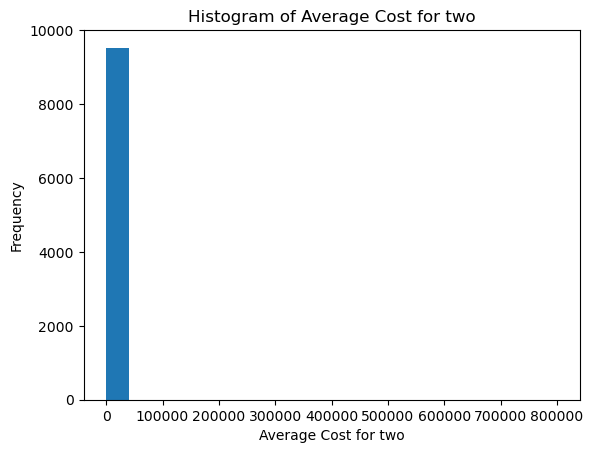

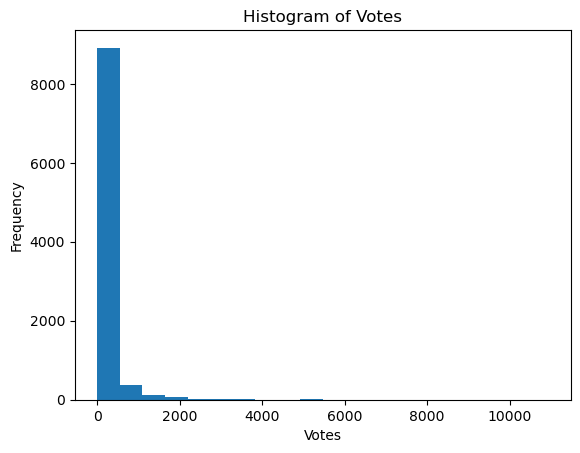

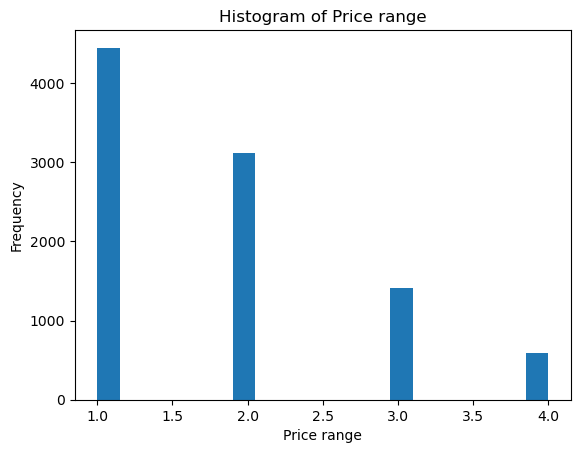

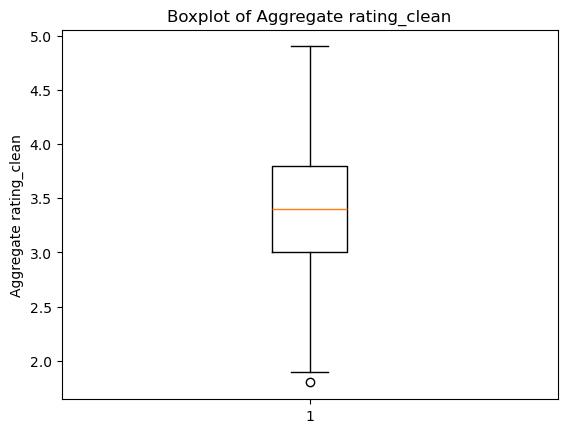

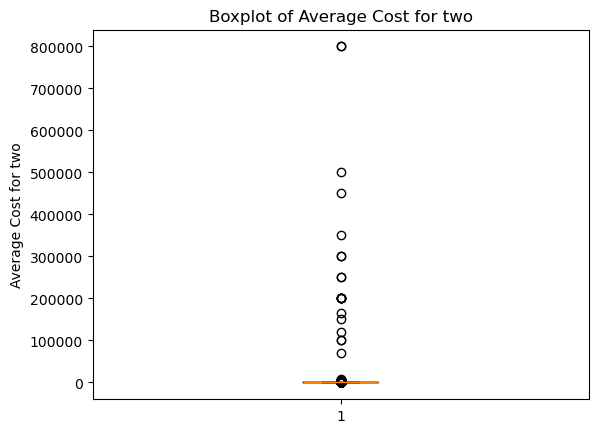

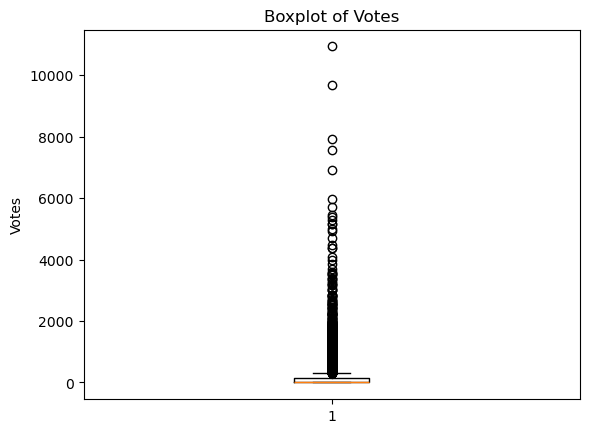

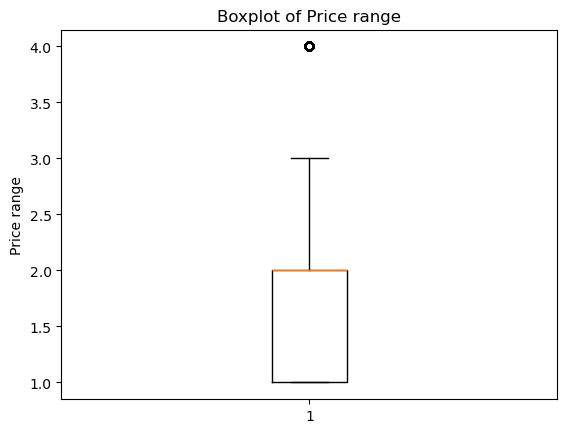

<Figure size 640x480 with 0 Axes>

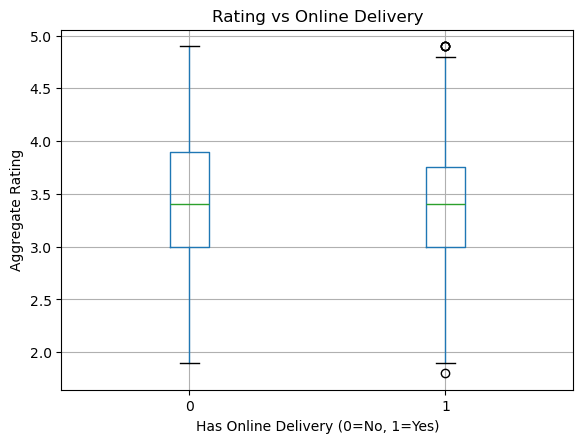

<Figure size 640x480 with 0 Axes>

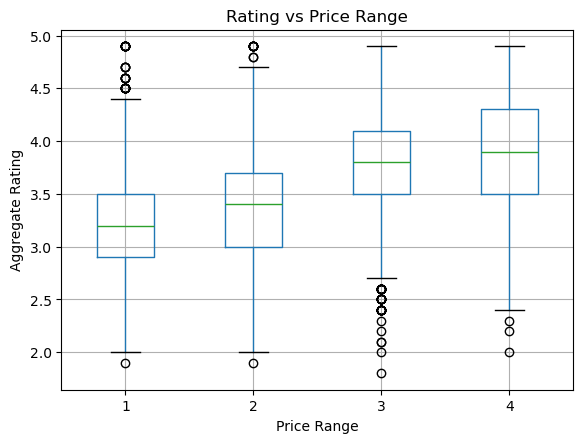

In [4]:
import matplotlib.pyplot as plt

numeric_cols = ["Aggregate rating_clean", "Average Cost for two", "Votes", "Price range"]

for col in numeric_cols:
    if col in df_clean.columns:
        plt.figure()
        plt.hist(df_clean[col].dropna(), bins=20)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

for col in numeric_cols:
    if col in df_clean.columns:
        plt.figure()
        plt.boxplot(df_clean[col].dropna())
        plt.title(f"Boxplot of {col}")
        plt.ylabel(col)
        plt.show()

plt.figure()
df_clean.boxplot(column="Aggregate rating_clean", by="Has Online delivery")
plt.title("Rating vs Online Delivery")
plt.suptitle("")  # removes extra title
plt.xlabel("Has Online Delivery (0=No, 1=Yes)")
plt.ylabel("Aggregate Rating")
plt.show()

plt.figure()
df_clean.boxplot(column="Aggregate rating_clean", by="Price range")
plt.title("Rating vs Price Range")
plt.suptitle("")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.show()
        

In [5]:
df_clean.to_csv("cleaned_dataset.csv", index=False)
print("Saved: cleaned_dataset.csv")


Saved: cleaned_dataset.csv
